In [ ]:
!pip install kagglehub

import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import tensorflow as tf
from sklearn.model_selection import train_test_split
import kagglehub

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, Model

In [ ]:
path = kagglehub.dataset_download("lakshaymiddha/crack-segmentation-dataset")
base_path = os.path.join(path, "crack_segmentation_dataset")

train_img_dir  = os.path.join(base_path, "train", "images")
train_mask_dir = os.path.join(base_path, "train", "masks")
test_img_dir   = os.path.join(base_path, "test", "images")
test_mask_dir  = os.path.join(base_path, "test", "masks")

Using Colab cache for faster access to the 'crack-segmentation-dataset' dataset.


In [ ]:
VALID_EXT = ('.png', '.jpg', '.jpeg')

def get_valid_files(img_dir, mask_dir):
    files = []
    for f in os.listdir(img_dir):
        if f.lower().endswith(VALID_EXT):
            if os.path.exists(os.path.join(mask_dir, f)):
                files.append(f)
    return files

train_files = get_valid_files(train_img_dir, train_mask_dir)
test_files  = get_valid_files(test_img_dir, test_mask_dir)

random.shuffle(train_files)
random.shuffle(test_files)

train_files = train_files[:1000]
test_files  = test_files[:300]

In [ ]:
IMG_SIZE = 256

def load_pair(img_path, mask_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32)

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
    mask = (mask > 127).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)

    return img, mask

In [ ]:
def load_dataset(files, img_dir, mask_dir):
    images, masks = [], []

    for f in tqdm(files):
        img, mask = load_pair(
            os.path.join(img_dir, f),
            os.path.join(mask_dir, f)
        )
        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

X_train, y_train = load_dataset(train_files, train_img_dir, train_mask_dir)
X_test,  y_test  = load_dataset(test_files, test_img_dir, test_mask_dir)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

100%|██████████| 300/300 [00:05<00:00, 56.22it/s]


Train: (1000, 256, 256, 3)
Test : (300, 256, 256, 3)


In [ ]:
X_train = preprocess_input(X_train)
X_test  = preprocess_input(X_test)

In [ ]:
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    random_state=42
)

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, Model

def build_pretrained_unet(input_shape=(256,256,3)):
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze encoder
    for layer in base_model.layers:
        layer.trainable = False

    s1 = base_model.get_layer("conv1_relu").output
    s2 = base_model.get_layer("conv2_block3_out").output
    s3 = base_model.get_layer("conv3_block4_out").output
    s4 = base_model.get_layer("conv4_block6_out").output

    b = base_model.get_layer("conv5_block3_out").output


    d1 = layers.Conv2DTranspose(256, 2, strides=2, padding="same")(b)
    d1 = layers.Concatenate()([d1, s4])
    d1 = layers.Conv2D(256, 3, padding="same", activation="relu")(d1)

    d2 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(d1)
    d2 = layers.Concatenate()([d2, s3])
    d2 = layers.Conv2D(128, 3, padding="same", activation="relu")(d2)

    d3 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(d2)
    d3 = layers.Concatenate()([d3, s2])
    d3 = layers.Conv2D(64, 3, padding="same", activation="relu")(d3)

    d4 = layers.Conv2DTranspose(32, 2, strides=2, padding="same")(d3)
    d4 = layers.Concatenate()([d4, s1])
    d4 = layers.Conv2D(32, 3, padding="same", activation="relu")(d4)

    d5 = layers.Conv2DTranspose(16, 2, strides=2, padding="same")(d4)
    d5 = layers.Conv2D(16, 3, padding="same", activation="relu")(d5)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d5)

    return Model(inputs=base_model.input, outputs=outputs)

In [ ]:
model = build_pretrained_unet((IMG_SIZE, IMG_SIZE, 3))


def dice_loss(y_true, y_pred):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    return 1 - (2. * tf.reduce_sum(y_true_f * y_pred_f) + 1e-6) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1e-6
    )

def bce_dice_loss(y_true, y_pred):
    bce = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))
    return bce + dice_loss(y_true, y_pred)

def iou_score(y_true, y_pred):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred > 0.5, tf.float32), [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + 1e-6) / (union + 1e-6)

def dice_coef(y_true, y_pred):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(tf.cast(y_pred > 0.5, tf.float32), [-1])
    return (2. * tf.reduce_sum(y_true_f * y_pred_f) + 1e-6) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + 1e-6
    )


model.compile(
    optimizer='adam',
    loss=bce_dice_loss,
    metrics=[iou_score, dice_coef]
)

print(model.output_shape)

model.summary()

(None, 256, 256, 1)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 29,760,625 (113.53 MB)

 Trainable params: 6,172,913 (23.55 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
]

history = model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=8
)

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 671s 6s/step - dice_coef: 0.3892 - iou_score: 0.2635 - loss: 0.7651 - val_dice_coef: 0.5211 - val_iou_score: 0.3558 - val_loss: 0.6485
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 663s 6s/step - dice_coef: 0.5917 - iou_score: 0.4264 - loss: 0.5329 - val_dice_coef: 0.5836 - val_iou_score: 0.4162 - val_loss: 0.5559
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 674s 6s/step - dice_coef: 0.6402 - iou_score: 0.4750 - loss: 0.4747 - val_dice_coef: 0.6039 - val_iou_score: 0.4376 - val_loss: 0.5135
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 652s 6s/step - dice_coef: 0.6636 - iou_score: 0.5017 - loss: 0.4427 - val_dice_coef: 0.6418 - val_iou_score: 0.4774 - val_loss: 0.4673
Epoch 5/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 642s 6s/step - dice_coef: 0.6823 - iou_score: 0.5228 - loss: 0.4171 - val_dice_coef: 0.6271 - val_iou_score: 0.4618 - val_loss: 0.4810
Epoch 6/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 688s 6s/step - dice_coef: 0.6973 - iou_score: 0.5394 - loss: 0.3974 - val_dice_coef: 

In [ ]:
results = model.evaluate(X_test, y_test, batch_size=8)

print("\nModel Performance ✅")
print(f"Loss      : {results[0]:.4f}")
print(f"IoU Score : {results[1]:.4f}")
print(f"Dice Coef : {results[2]:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 104s 3s/step - dice_coef: 0.6472 - iou_score: 0.4839 - loss: 0.4778

Model Performance ✅
Loss      : 0.4778
IoU Score : 0.4839
Dice Coef : 0.6472


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


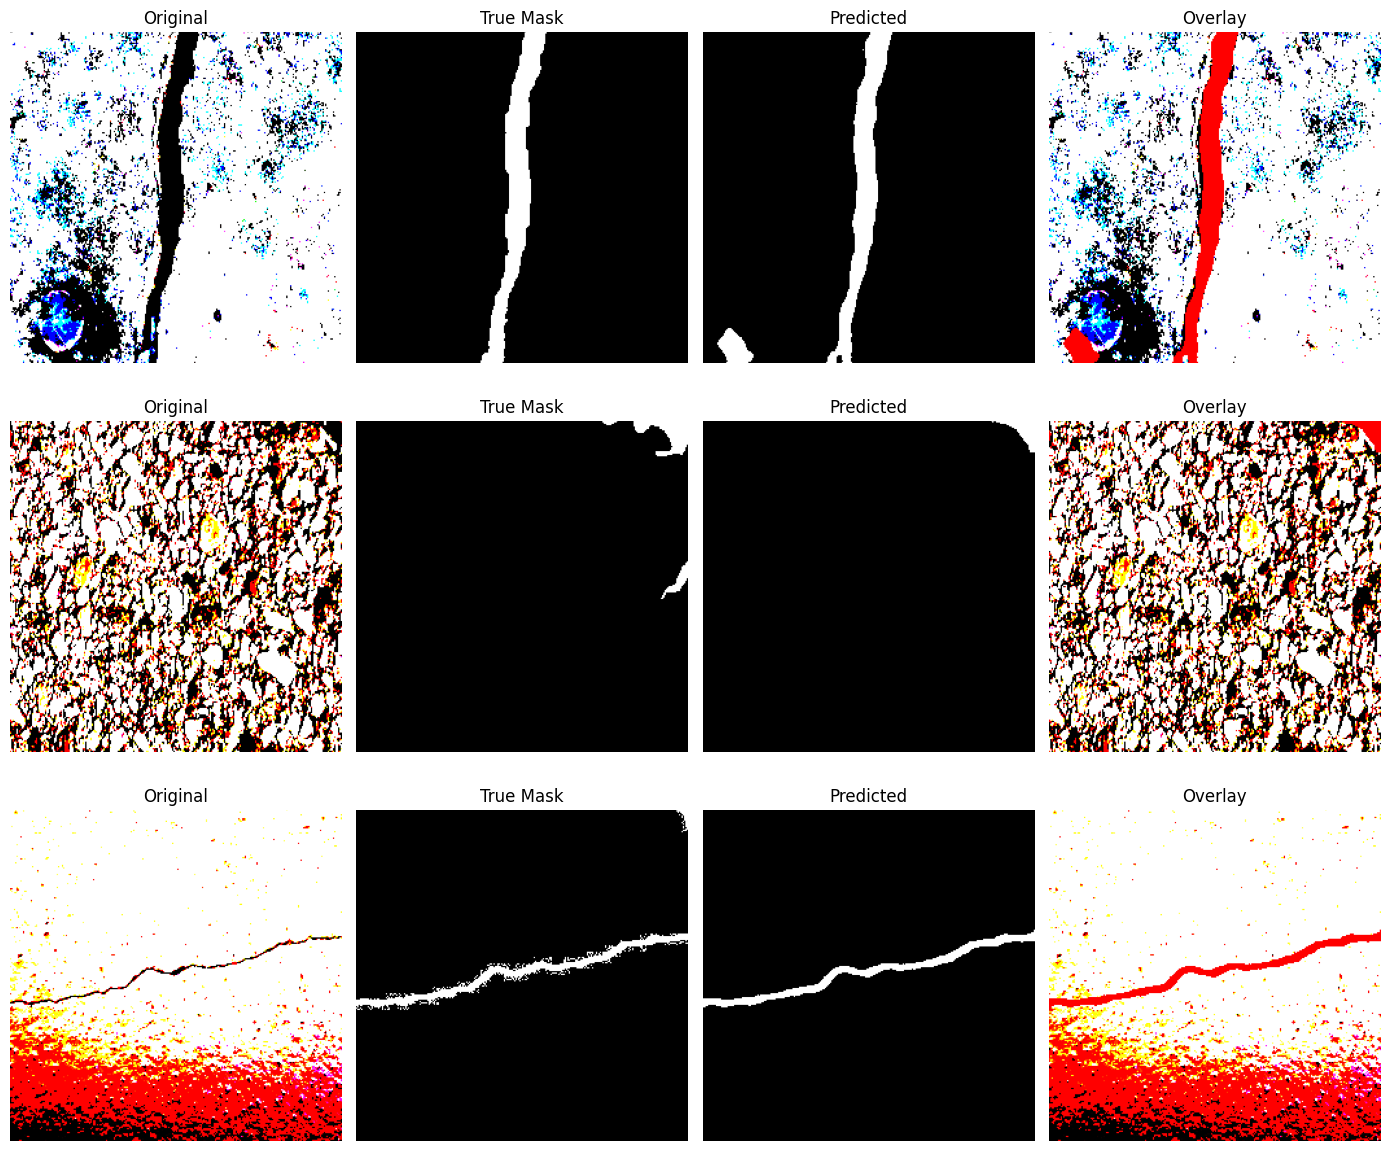

In [ ]:
import random

preds = model.predict(X_test[:20])

k = min(3, len(preds))
indices = random.sample(range(len(preds)), k)

fig, axes = plt.subplots(k, 4, figsize=(14, 4*k))

if k == 1:
    axes = [axes]

for row, i in enumerate(indices):
    img  = X_test[i]
    true = y_test[i].squeeze()
    pred = preds[i].squeeze()

    pred_mask = (pred > 0.3).astype(np.float32)

    overlay = img.copy()
    overlay[pred_mask > 0.5] = [1, 0, 0]

    axes[row][0].imshow(img)
    axes[row][0].set_title("Original")

    axes[row][1].imshow(true, cmap="gray")
    axes[row][1].set_title("True Mask")

    axes[row][2].imshow(pred_mask, cmap="gray")
    axes[row][2].set_title("Predicted")

    axes[row][3].imshow(overlay)
    axes[row][3].set_title("Overlay")

    for j in range(4):
        axes[row][j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
for i in indices:
    crack_percentage = preds[i].mean() * 100

    if crack_percentage < 1:
        severity = "LOW"
    elif crack_percentage < 5:
        severity = "MEDIUM"
    else:
        severity = "HIGH"

    print(f"Image {i}: Crack = {crack_percentage:.2f}% → {severity}")

Image 2: Crack = 3.84% → MEDIUM
Image 9: Crack = 0.91% → LOW
Image 14: Crack = 8.25% → HIGH


In [ ]:
def predict_image(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    img_norm = preprocess_input(img_resized.astype(np.float32))

    pred = model.predict(np.expand_dims(img_norm, axis=0))[0]

    mask = (pred > 0.3).astype(np.float32)

    mask = cv2.resize(mask, (img.shape[1], img.shape[0]))

    overlay = img_rgb.copy()
    overlay[mask > 0.5] = [255, 0, 0]

    crack_percentage = mask.mean() * 100

    if crack_percentage < 1:
        severity = "LOW"
    elif crack_percentage < 5:
        severity = "MEDIUM"
    else:
        severity = "HIGH"

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Original")
    plt.imshow(img_rgb)
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.title("Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title(f"Overlay ({severity})")
    plt.imshow(overlay)
    plt.axis("off")

    plt.show()

    print(f"Crack Percentage: {crack_percentage:.2f}%")
    print(f"Risk Severity   : {severity}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step


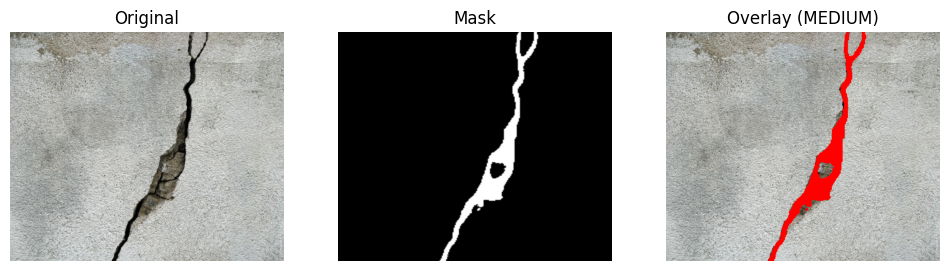

Crack Percentage: 4.11%
Risk Severity   : MEDIUM


In [ ]:
predict_image("/content/test.jpeg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step


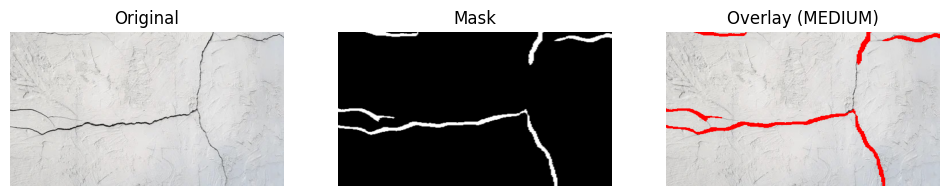

Crack Percentage: 3.78%
Risk Severity   : MEDIUM


In [ ]:
predict_image("/content/test2.jpeg")

In [ ]:
model.save("crack_pretrained_model.keras")
print("Model saved ✅")

Model saved ✅
